In [1]:
from pathlib import Path

dataset = Path("../../Datasets_for_my_practice/road_objects/Road-Anomalies-1/")

print(dataset.exists())


True


In [2]:
import yaml
import os

data_yaml = os.path.join(dataset, "data.yaml")

with open(data_yaml, "r") as f:
    data = yaml.safe_load(f)

print(data)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 19, 'names': ['Cracks', 'Lane', 'SpeedBreaker', 'Speed_Breaker', 'bicycle', 'bus', 'car', 'construction sign', 'crosswalk', 'motorcycle', 'one way sign', 'pedestrian crossing sign', 'person', 'pothole', 'railroad sign', 'stop sign', 'street name sign', 'traffic light', 'truck'], 'roboflow': {'workspace': 'major-project-zlyw3', 'project': 'road-anomalies-omxxj', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/major-project-zlyw3/road-anomalies-omxxj/dataset/1'}}


In [3]:
train_images = len(list((dataset / "train/images").glob("*")))

valid_images = len(list((dataset / "valid/images").glob("*")))

test_images = len(list((dataset / "test/images").glob("*")))

print(train_images)
print(valid_images)
print(test_images)

1997
250
250


In [4]:
train_images = dataset / "train" / "images"

print(train_images)
print(train_images.exists())

..\..\Datasets_for_my_practice\road_objects\Road-Anomalies-1\train\images
True


In [5]:
image_paths = sorted(train_images.glob("*"))
print("Total Images: ", len(image_paths))

Total Images:  1997


In [6]:
image_path = image_paths[0]

print(image_path)

..\..\Datasets_for_my_practice\road_objects\Road-Anomalies-1\train\images\-0QOcberQNw6ARnggEAWuA_jpg.rf.6fe6f94d1b4c119c73d048908f10bfeb.jpg


In [7]:
import cv2
image = cv2.imread(str(image_path))

In [8]:
if image is None:
    print("Image could not be loaded.")
else:
    print("Image loaded successfully!")

Image loaded successfully!


In [9]:
print(image.shape)

(640, 640, 3)


In [10]:
height, width, channels = image.shape
print(f"Height: {height}")
print(f"Width: {width}")
print(f"Channels: {channels}")

Height: 640
Width: 640
Channels: 3


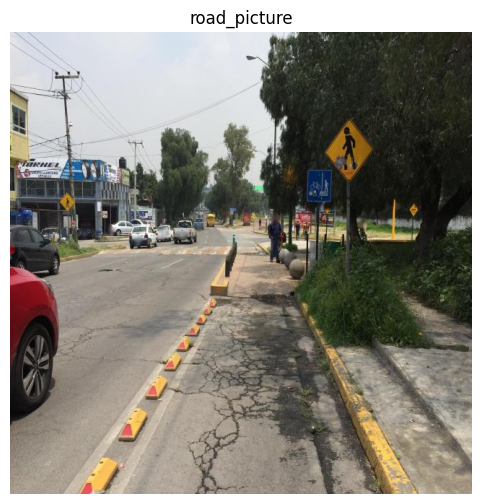

In [11]:
import matplotlib.pyplot as plt

image_rgb = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

plt.figure(figsize=[10,6])
plt.imshow(image_rgb)
plt.title("road_picture")
plt.axis("off")
plt.show()

In [12]:
print(image_path.stem)

label_path = (
    image_path.parent.parent
    / "labels"
    / f"{image_path.stem}.txt"
)

print(label_path.exists())

with open(label_path, "r") as f:
    lines = f.readlines()
    
print(lines)

-0QOcberQNw6ARnggEAWuA_jpg.rf.6fe6f94d1b4c119c73d048908f10bfeb
True
['12 0.57578125 0.4484375 0.03984375 0.11484375\n', '6 0.05703125 0.66171875 0.1140625 0.3515625\n', '8 0.3453125 0.46953125 0.27109375 0.0390625\n', '16 0.5390625 0.33984375 0.0296875 0.0171875\n', '11 0.7328125 0.25703125 0.12890625 0.15\n', '11 0.12578125 0.36953125 0.0421875 0.05234375\n', '6 0.05703125 0.4703125 0.11328125 0.10625\n', '6 0.2921875 0.44375 0.059375 0.05390625\n', '6 0.38046875 0.4359375 0.05859375 0.05\n', '6 0.16328125 0.42265625 0.04296875 0.0484375\n', '6 0.08984375 0.4390625 0.0484375 0.0375\n', '6 0.27890625 0.41015625 0.04375 0.01484375\n', '6 0.334375 0.434375 0.0375 0.0390625\n', '6 0.409375 0.415625 0.0234375 0.02734375\n', '18 0.43515625 0.40859375 0.02265625 0.0328125\n', '6 0.240625 0.42265625 0.05859375 0.02734375\n', '12 0.76484375 0.42578125 0.01796875 0.04609375\n', '12 0.640625 0.4296875 0.015625 0.046875\n', '12 0.621875 0.43203125 0.0140625 0.04921875\n', '12 0.61015625 0.4304687

In [13]:
line = lines[2]

print(line)

8 0.3453125 0.46953125 0.27109375 0.0390625



In [14]:
parts = line.strip().split()

print(parts)

['8', '0.3453125', '0.46953125', '0.27109375', '0.0390625']


In [15]:
class_id = int(parts[0])

x_center = float(parts[1])
y_center = float(parts[2])
width_normalized = float(parts[3])
height_normalized = float(parts[4])

In [16]:
x_center = x_center * width
y_center = y_center * height

box_width = width_normalized * width
box_height = height_normalized * height

In [17]:
x_min = x_center - box_width/2
y_min = y_center - box_height/2

x_max = x_center + box_width/2
y_max = y_center + box_height/2

x_min = round(x_min)
y_min = round(y_min)

x_max = round(x_max)
y_max = round(y_max)

In [18]:
print(f"x_min: {x_min}, y_min: {y_min}")
print(f"x_max: {x_max}, y_max: {y_max}")
print(f"Image Width: {width}, Image Height: {height}")

x_min: 134, y_min: 288
x_max: 308, y_max: 313
Image Width: 640, Image Height: 640


In [19]:
cv2.rectangle(image,(x_min,y_min),(x_max,y_max),(0,255,0),2)

class_name = data["names"][class_id]

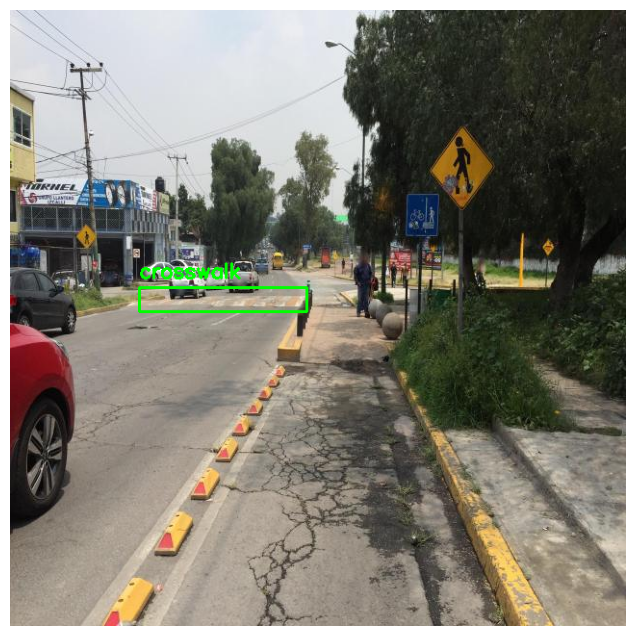

In [20]:
cv2.putText(
    image,
    class_name,
    (x_min, y_min - 10),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.7,
    (0, 255, 0),
    2
)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,8))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

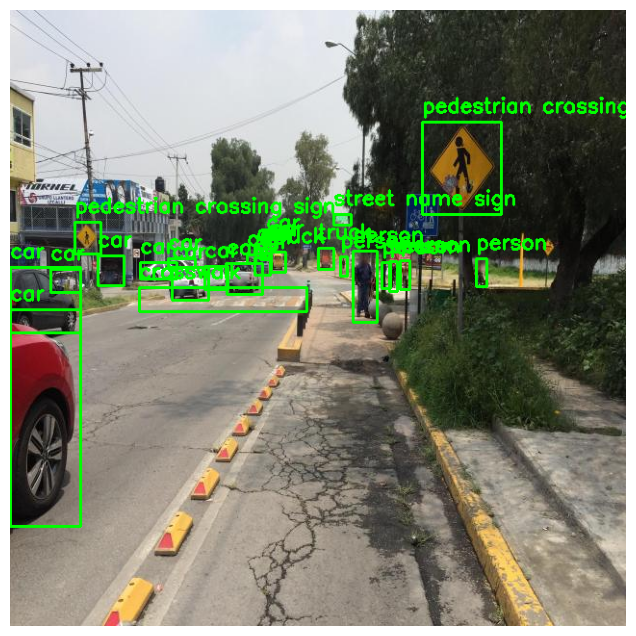

In [21]:
for line in lines:
    parts = line.strip().split()
    
    class_id = int(parts[0])

    x_center = float(parts[1])
    y_center = float(parts[2])
    width_normalized = float(parts[3])
    height_normalized = float(parts[4])
    
    x_center = x_center * width
    y_center = y_center * height

    box_width = width_normalized * width
    box_height = height_normalized * height
    
    x_min = x_center - box_width/2
    y_min = y_center - box_height/2

    x_max = x_center + box_width/2
    y_max = y_center + box_height/2

    x_min = round(x_min)
    y_min = round(y_min)

    x_max = round(x_max)
    y_max = round(y_max)

    cv2.rectangle(image,(x_min,y_min),(x_max,y_max),(0,255,0),2)

    class_name = data["names"][class_id]

    cv2.putText(
        image,
        class_name,
        (x_min, y_min - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 0),
        2
    )

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,8))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()
    

## Dataset Analysis

In [22]:
import yaml
import os

data_yaml = os.path.join(dataset, "data.yaml")

with open(data_yaml, "r") as f:
    data = yaml.safe_load(f)

print(data["names"])

['Cracks', 'Lane', 'SpeedBreaker', 'Speed_Breaker', 'bicycle', 'bus', 'car', 'construction sign', 'crosswalk', 'motorcycle', 'one way sign', 'pedestrian crossing sign', 'person', 'pothole', 'railroad sign', 'stop sign', 'street name sign', 'traffic light', 'truck']


In [23]:
class_names = data["names"]

# Initialize counts for each class
class_counts = {name: 0 for name in class_names}
print(class_names[0])

Cracks


In [24]:


for split in dataset.iterdir():
    # print(split)
    
    if not split.is_dir():
        continue
    print(split)    
    # for folder in split.iterdir():
        # print(folder)
    image_paths = sorted((split / "images" ).glob("*"))
    # print(len(image_paths))
    
    for image in image_paths:
        # print(1)
        # print(image.stem)
        label_path = (image.parent.parent / "labels" / f"{image.stem}.txt")
        # print(2)
        # print(label_path)
        with open(label_path, "r") as f:
            lines = f.readlines()
        
        # print(lines[0])
        for line in lines:
            parts = line.strip().split()
            
            class_id = int(parts[0])
            if class_id < len(class_names):
                class_name = class_names[class_id]
                class_counts[class_name] += 1


print(class_counts)
                    
                    
            

..\..\Datasets_for_my_practice\road_objects\Road-Anomalies-1\test
..\..\Datasets_for_my_practice\road_objects\Road-Anomalies-1\train
..\..\Datasets_for_my_practice\road_objects\Road-Anomalies-1\valid
{'Cracks': 1428, 'Lane': 769, 'SpeedBreaker': 3, 'Speed_Breaker': 567, 'bicycle': 32, 'bus': 33, 'car': 2126, 'construction sign': 122, 'crosswalk': 281, 'motorcycle': 64, 'one way sign': 106, 'pedestrian crossing sign': 272, 'person': 352, 'pothole': 1326, 'railroad sign': 91, 'stop sign': 64, 'street name sign': 432, 'traffic light': 1003, 'truck': 483}


In [25]:
from pathlib import Path

# Dictionary: {"car": 0, "bus": 0, ...}
class_counts = {class_name: 0 for class_name in class_names}

total_images = 0

for split in dataset.iterdir():

    if not split.is_dir():
        continue

    print(f"\nProcessing: {split.name}")

    image_paths = sorted((split / "images").glob("*"))
    print(f"Images: {len(image_paths)}")

    total_images += len(image_paths)

    for image in image_paths:

        label_path = (
            image.parent.parent
            / "labels"
            / f"{image.stem}.txt"
        )

        # Skip if label file does not exist
        if not label_path.exists():
            print(f"Warning: Missing label -> {label_path.name}")
            continue

        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:

            parts = line.strip().split()

            class_id = int(parts[0])

            # Check whether class_id is valid
            assert 0 <= class_id < len(class_names), (
                f"Invalid class_id {class_id} in {label_path}"
            )

            class_name = class_names[class_id]

            class_counts[class_name] += 1


# ------------------------------
# Dataset Statistics
# ------------------------------

total_objects = sum(class_counts.values())

print("\n" + "=" * 50)
print("DATASET SUMMARY")
print("=" * 50)

print(f"Total Images  : {total_images}")
print(f"Total Objects : {total_objects}")
print(f"Total Classes : {len(class_names)}")
print(f"Average Objects/Image : {total_objects / total_images:.2f}")

print("\n" + "=" * 50)
print("OBJECTS PER CLASS")
print("=" * 50)

# Sort from highest to lowest
for class_name, count in sorted(
    class_counts.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{class_name:<25} : {count}")


Processing: test
Images: 250

Processing: train
Images: 1997

Processing: valid
Images: 250

DATASET SUMMARY
Total Images  : 2497
Total Objects : 9554
Total Classes : 19
Average Objects/Image : 3.83

OBJECTS PER CLASS
car                       : 2126
Cracks                    : 1428
pothole                   : 1326
traffic light             : 1003
Lane                      : 769
Speed_Breaker             : 567
truck                     : 483
street name sign          : 432
person                    : 352
crosswalk                 : 281
pedestrian crossing sign  : 272
construction sign         : 122
one way sign              : 106
railroad sign             : 91
motorcycle                : 64
stop sign                 : 64
bus                       : 33
bicycle                   : 32
SpeedBreaker              : 3
